In [1]:
from qiskit_ibm_runtime import QiskitRuntimeService
 
service = QiskitRuntimeService()
backend = service.backend("ibm_fez")
 
target = backend.target
basis_gates = list(target.operation_names)

management.get:WARNING:2025-12-10 16:28:41,388: Loading default saved account


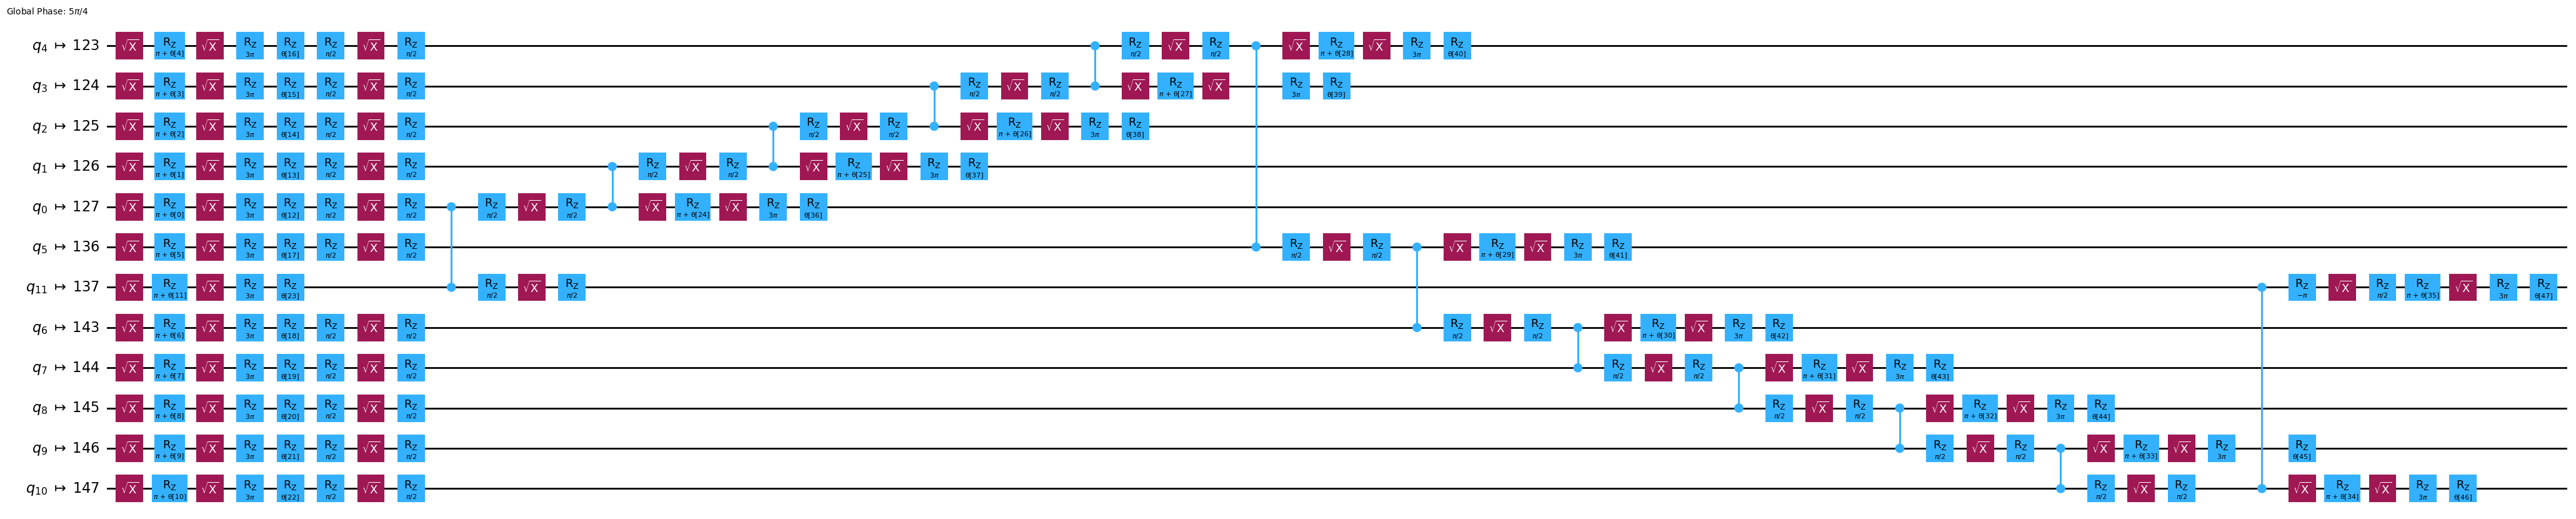

In [2]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.circuit.library import efficient_su2
 
qc = efficient_su2(12, entanglement="circular", reps=1)
pm = generate_preset_pass_manager(1, target=target, seed_transpiler=12345)
qc_t = pm.run(qc)
qc_t.draw("mpl", fold=-1, idle_wires=False)

In [3]:
from qiskit.circuit.library import XGate, YGate
 
X = XGate()
Y = YGate()
 
dd_sequence = [X, Y, X, Y]

In [4]:
from qiskit.transpiler import InstructionProperties
 
y_gate_properties = {}
for qubit in range(target.num_qubits):
    y_gate_properties.update(
        {
            (qubit,): InstructionProperties(
                duration=target["x"][(qubit,)].duration,
                error=target["x"][(qubit,)].error,
            )
        }
    )
 
target.add_instruction(YGate(), y_gate_properties)

In [14]:
target.operation_names

dict_keys(['reset', 'rz', 'cz', 'x', 'measure', 'sx', 'delay', 'if_else', 'id', 'y'])

In [16]:
new_target = backend.target
new_target.operation_names

dict_keys(['reset', 'rz', 'cz', 'x', 'measure', 'sx', 'delay', 'if_else', 'id', 'y'])

In [5]:
import numpy as np
 
rng = np.random.default_rng(1234)
qc_t.assign_parameters(
    rng.uniform(-np.pi, np.pi, qc_t.num_parameters), inplace=True
)

In [17]:
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes.scheduling import (
    ALAPScheduleAnalysis,
    PadDynamicalDecoupling,
)
 
dd_pm = PassManager(
    [
        ALAPScheduleAnalysis(target=target),
        PadDynamicalDecoupling(target=target, dd_sequence=dd_sequence),
    ]
)
qc_dd = dd_pm.run(qc_t)

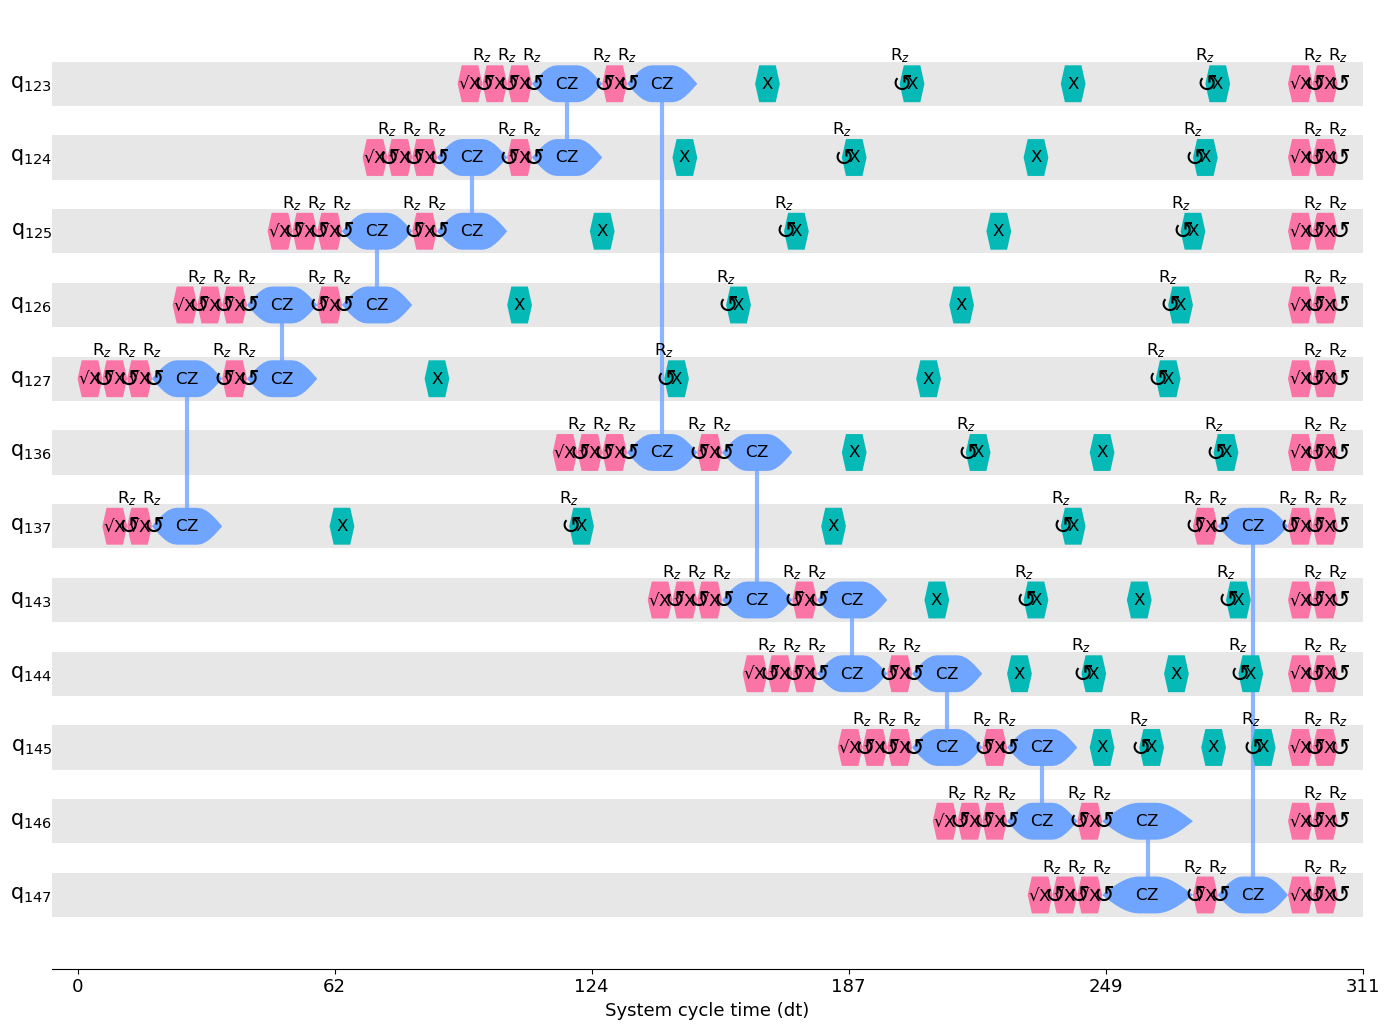

In [18]:
from qiskit.circuit.equivalence_library import (
    SessionEquivalenceLibrary as sel,
)
from qiskit.transpiler.passes import BasisTranslator
 
qc_dd = BasisTranslator(sel, basis_gates)(qc_dd)
# qc_dd.draw("mpl", fold=-1, idle_wires=False)
timeline_drawer(qc_dd, idle_wires=False, target=target)

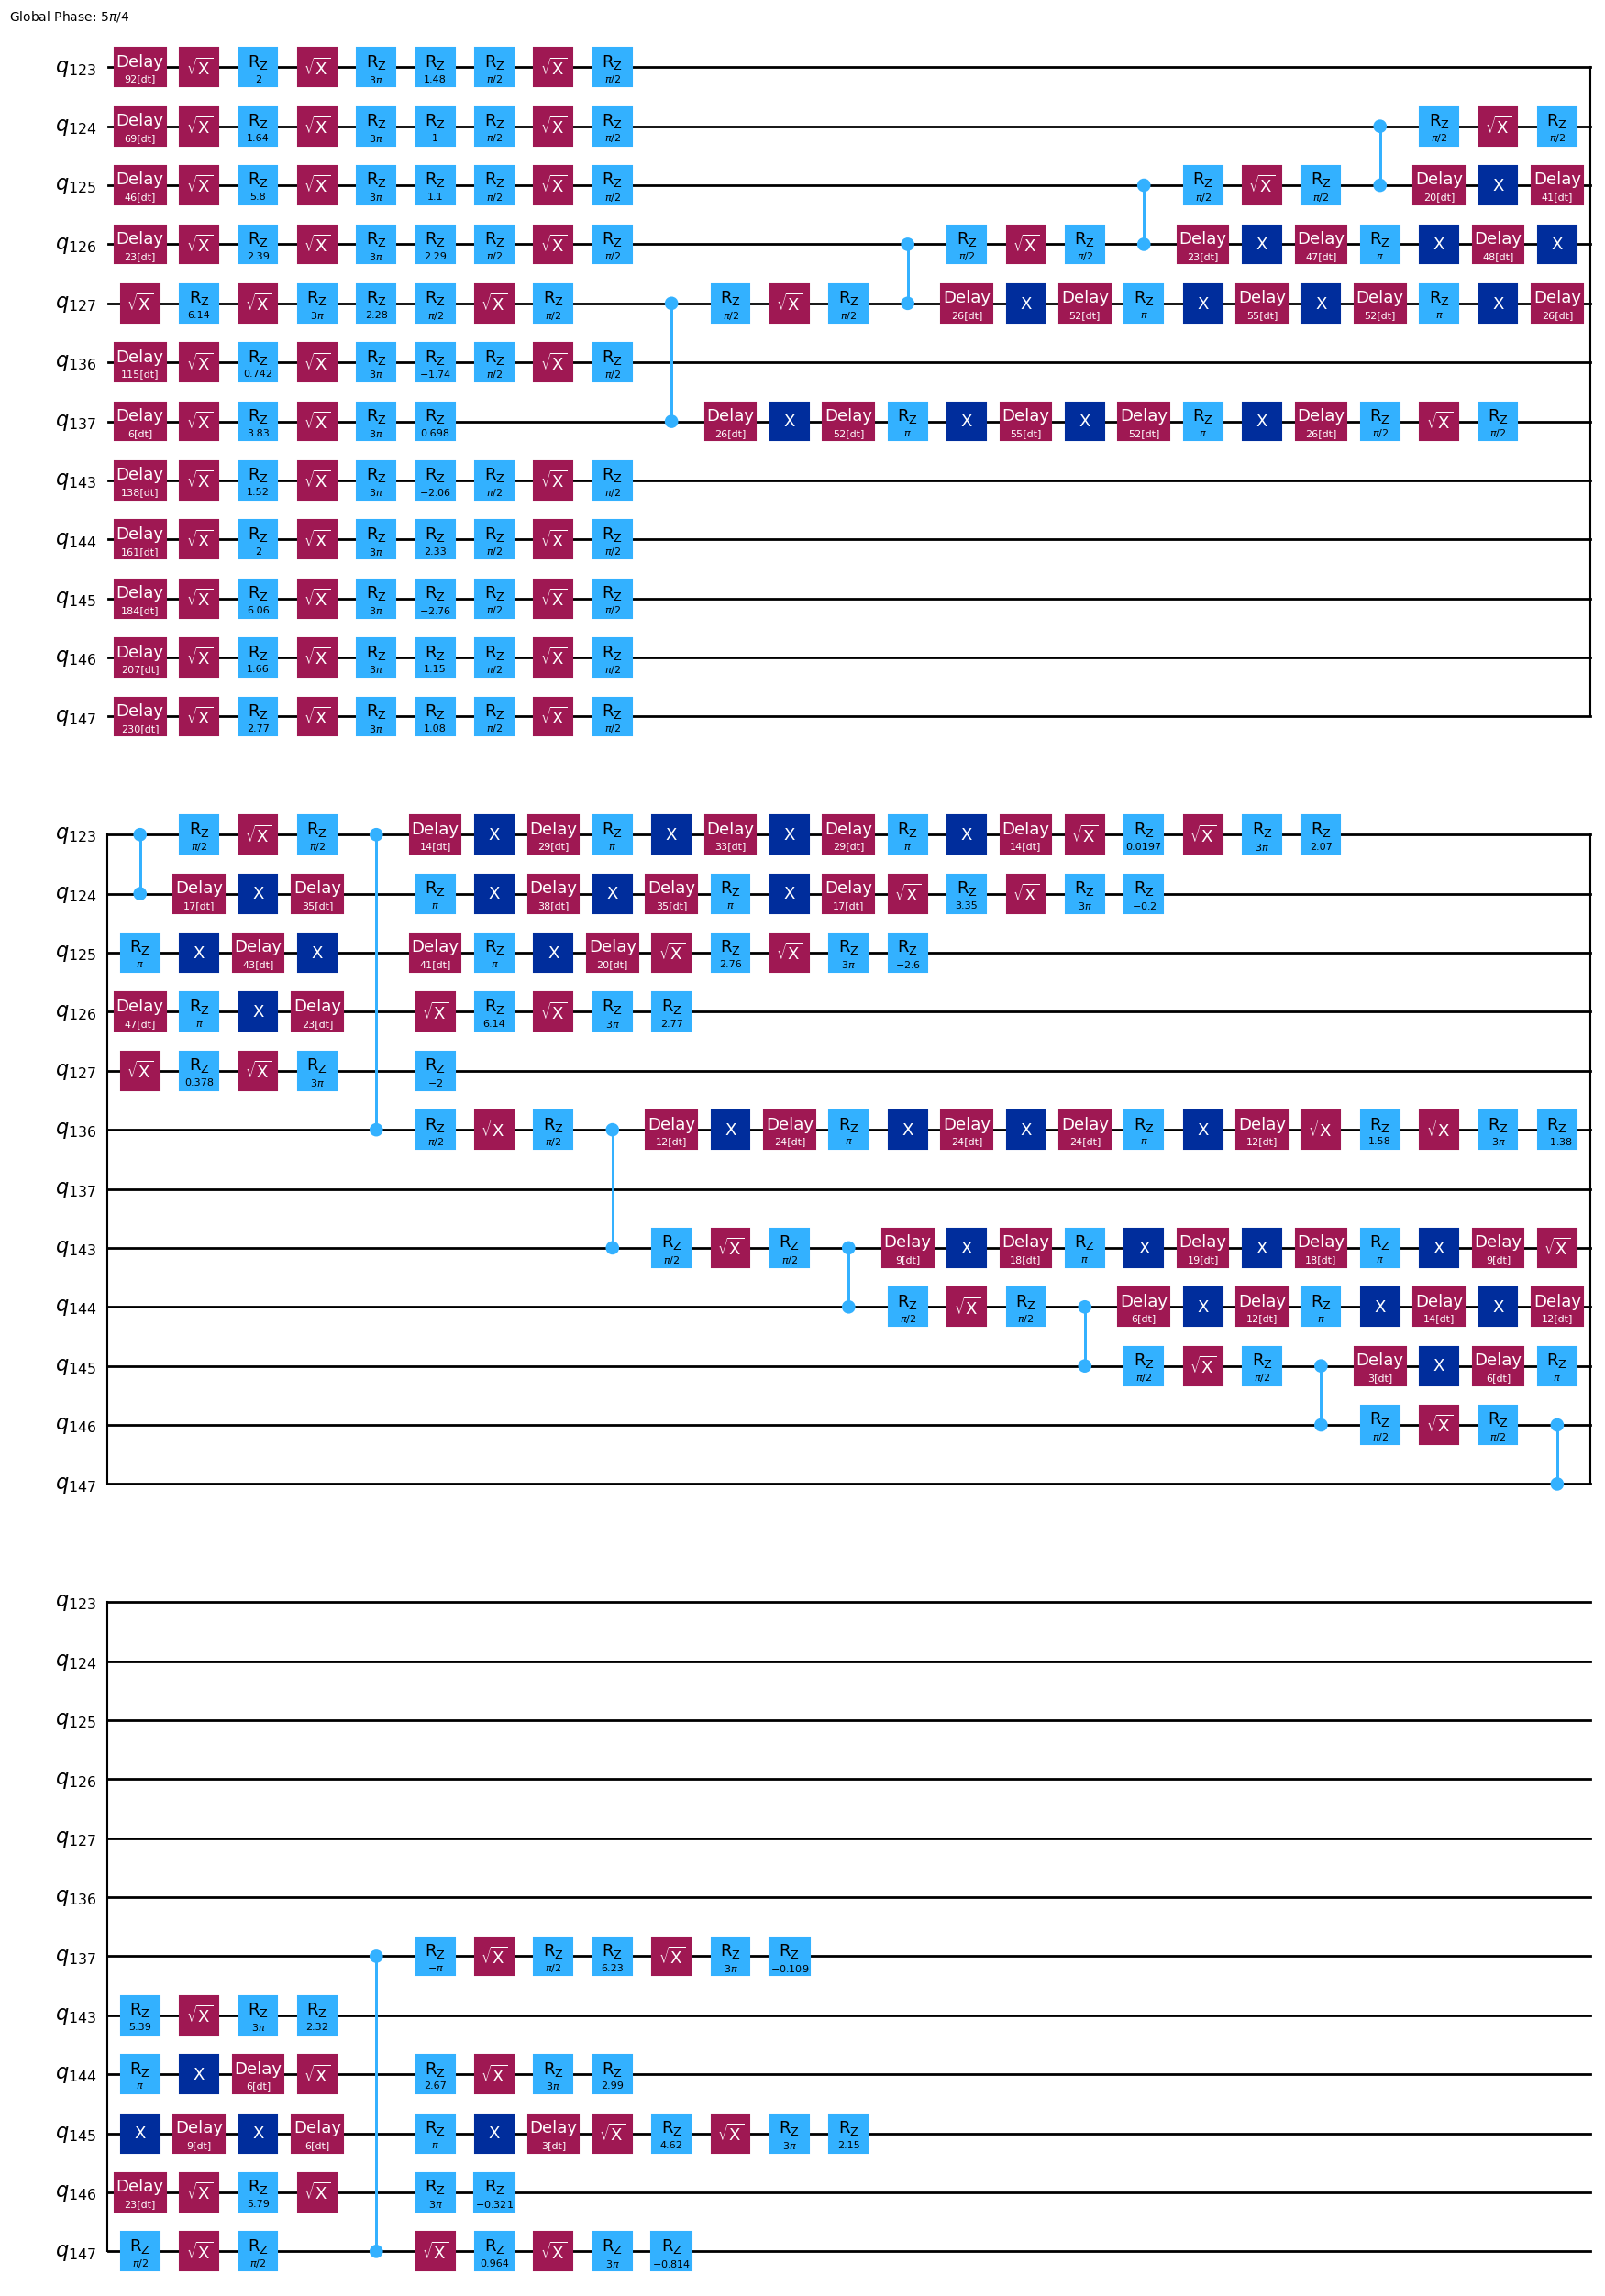

In [20]:
qc_dd.draw("mpl", idle_wires=False)